## ODS Project
### Optimization Methods for Clustering
Done by: Liliia Ivanovskaia and Adrian Valentin Josef Seidl

In [1]:
# Imports
import urllib.request
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import time

### Datasets

In [2]:
url = ["https://mat.tepper.cmu.edu/COLOR02/INSTANCES/C250.9.clq",
       "https://mat.tepper.cmu.edu/COLOR02/INSTANCES/brock200_2.clq",
       "https://mat.tepper.cmu.edu/COLOR02/INSTANCES/gen400_p0.9_65.clq"]

filenames = ["C250.9", "brock200_2", "gen400_p0.9_65"]
n_graph = len(filenames)

for i in range(n_graph):
    urllib.request.urlretrieve(url[i], filenames[i])

In [3]:
def parse_dimacs_clq(filepath):
    A = nx.Graph()

    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('e'):
                _, u, v = line.strip().split()
                A.add_edge(int(u), int(v))

    A = nx.to_numpy_array(A, nodelist = sorted(A.nodes()), dtype = int)

    return A

In [4]:
A = n_graph * [None]

for i, filename in enumerate(filenames):
    A[i] = parse_dimacs_clq(filename)
    print(f"{filename}.clq: {A[i].shape} edges: {np.count_nonzero(np.triu(A[0]))}")

C250.9.clq: (250, 250) edges: 27984
brock200_2.clq: (200, 200) edges: 27984
gen400_p0.9_65.clq: (400, 400) edges: 27984


### Vizualization of the network datasets

In [5]:
def visualize_graph_from_adjacency(A, max_nodes=50, title="Graph"):
  G = nx.from_numpy_array(A)
  if len(G) > max_nodes:
    print(f"Graph is too big ({len(G)} nodes), show first {max_nodes}")
    G = G.subgraph(list(G.nodes)[:max_nodes])

  pos = nx.spring_layout(G, seed=42)
  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, node_color='skyblue', edge_color='gray', with_labels=True,
          node_size=300, font_size=10)
  plt.title(title)
  plt.axis('off')
  plt.show()

Graph is too big (250 nodes), show first 50


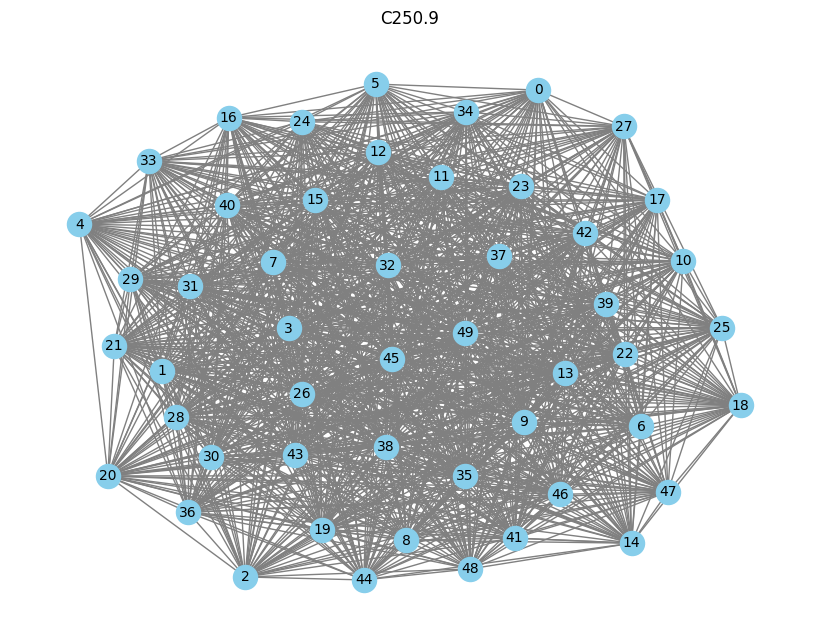

In [6]:
visualize_graph_from_adjacency(A[0], title="C250.9")

Graph is too big (200 nodes), show first 50


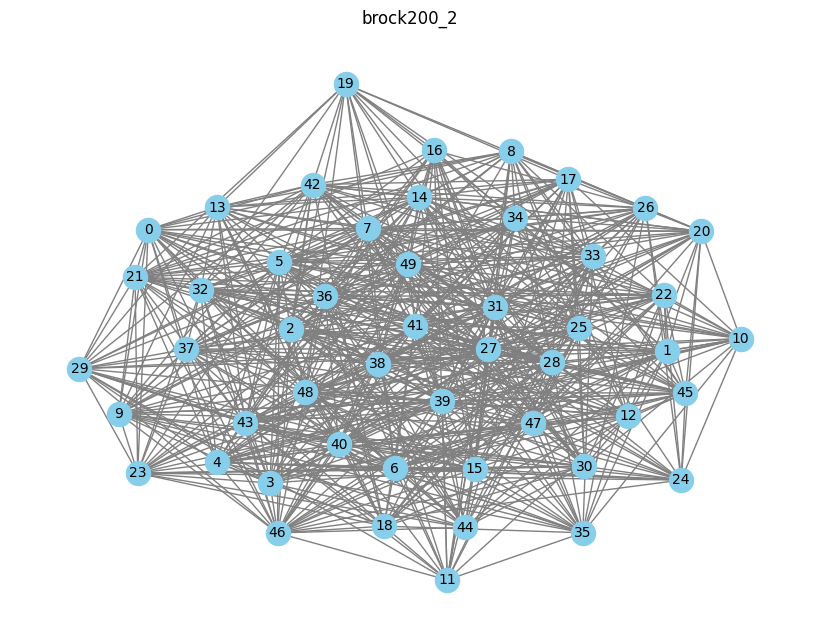

In [7]:
visualize_graph_from_adjacency(A[1], title="brock200_2")

Graph is too big (400 nodes), show first 50


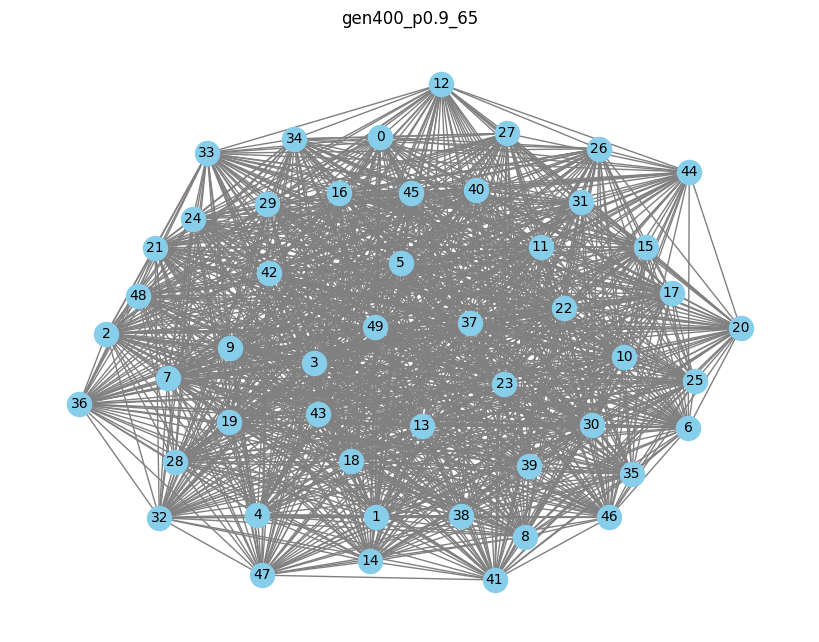

In [8]:
visualize_graph_from_adjacency(A[2], title="gen400_p0.9_65")

### Application of algorithm for datasets

In [9]:
# additional functions (lmo, ...)

def lmo(grad):
  # LMO over simplex
  s = np.zeros_like(grad)
  s[np.argmin(grad)] = 1.0
  return s

def loss_no_reg(x):
    return 0

def grad_no_reg(x):
    return np.zeros_like(x)

def loss_reg_B(x):
    return 0.5 * np.sum(x**2)

def loss_reg_1(x, epsilon, p, alpha):
    if epsilon <= 0:
        raise ValueError(f"epsilon = {epsilon} > 0 == FALSE")
    if p <=2:
        raise ValueError(f"p = {p} > 2 == FALSE")
    alpha_max = 2 / (p * (p - 1) * (1 + epsilon)**(p - 2))
    if not(0 < alpha < alpha_max):
        raise ValueError(f"0 < alpha = {alpha} < {alpha_max} == FALSE")

    return alpha * np.sum(np.abs(x + epsilon) ** p)**(1 / p)

def loss_reg_2(x, beta, alpha):
    if beta <= 0:
        raise ValueError(f"beta = {beta} > 0 == FALSE")
    alpha_max = 2 / beta**2
    if not(0 < alpha < alpha_max):
        raise ValueError(f"0 < alpha = {alpha} < {alpha_max} == FALSE")

    return alpha * np.sum(np.exp(-beta * x) - 1)

def grad_reg_B(x):
    return x

def grad_reg_1(x, epsilon, p, alpha):
    if epsilon <= 0:
        raise ValueError(f"epsilon = {epsilon} > 0 == FALSE")
    if p <=2:
        raise ValueError(f"p = {p} > 2 == FALSE")
    alpha_max = 2 / (p * (p - 1) * (1 + epsilon)**(p - 2))
    if not(0 < alpha < alpha_max):
        raise ValueError(f"0 < alpha = {alpha} < {alpha_max} == FALSE")

    val_abs = np.abs(x + epsilon)
    return alpha * np.sum(val_abs ** p) ** ((1 - p) / p) * (val_abs**(p - 1)) * np.sign(x + epsilon)

def grad_reg_2(x, beta, alpha):
    if beta <= 0:
        raise ValueError(f"beta = {beta} > 0 == FALSE")
    alpha_max = 2 / beta**2
    if not(0 < alpha < alpha_max):
        raise ValueError(f"0 < alpha = {alpha} < {alpha_max} == FALSE")

    return - alpha * beta * np.exp(-beta * x)

def f_objective(x, A, loss_reg):
  # f(x) = -x^T A x + (1/2) * ||x||^2 from the article
  return - x.T @ A @ x + loss_reg

def grad_f(x, A, grad_reg):

  # gradient of the objective function f(x): ∇f(x) = -2 A x + x
  return - 2 * A @ x + grad_reg

In [10]:
n_iter = 300
tol = 1e-6

### Basic Frank Wolfe

In [11]:
# abstract basic Frank Wolf function
def frank_wolfe(f, grad_f, x0, lmo, tol=1e-6, n_iter=100):
  """
  Frank-Wolfe algorithm with classical stepsize α_k = 2 / (k + 2).

  Parameters:
      f       : function f(x) to minimize
      grad_f  : gradient ∇f(x)
      x0      : initial point x0 ∈ C
      lmo     : Linear Minimization Oracle: returns argmin_s ∇f(x)^T s over s ∈ C
      n_iter  : number of iterations

  Returns:
      trajectory : list of all iterates x_k
      history    : dictionary with convergence metrics (f_val, gap, nnz)
  """
  x = x0.copy()
  trajectory = [x.copy()]
  history = {
        'f_val': [f(x)],
        'gap': [],
        'nnz': [np.count_nonzero(x)],
        'time': []
    }
  start_time = time.time()


  for k in range(1, n_iter + 1):

    grad = grad_f(x)
    s = lmo(grad)
    gap = grad @ (x - s)
    history['gap'].append(gap)

    if gap < tol:
      print(f"Stopped at iteration {k}, dual gap = {gap:.2e}")
      break

    alpha = 2 / (k + 2)
    x = x + alpha * (s - x)
    trajectory.append(x.copy())
    history['f_val'].append(f(x))
    history['nnz'].append(np.count_nonzero(x))
    history['time'].append(time.time() - start_time)

  return np.array(trajectory), history

First dataset

In [12]:
traj_fw = n_graph * [None]
history_fw = n_graph * [None]

for i in range(n_graph):
    x0 = np.ones(A[i].shape[0]) / A[i].shape[0]

    traj_fw[i], history_fw[i] = frank_wolfe(
        f=lambda x: f_objective(x, A[i], loss_reg_B(x)),
        grad_f=lambda x: grad_f(x, A[i], grad_reg_B(x)),
        x0=x0,
        lmo=lmo,
        n_iter=n_iter,
        tol=tol
    )

In [13]:
x_star = traj_fw[0][-1] # value, which minimizes a convex function
x_star

array([8.80068645e-08, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       8.80068645e-08, 2.39379552e-02, 8.80068645e-08, 8.69076588e-03,
       6.35858397e-03, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       8.80068645e-08, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       2.72382126e-02, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       8.80068645e-08, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       8.80068645e-08, 2.55440804e-02, 8.80068645e-08, 8.80068645e-08,
       2.62041319e-02, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       8.80068645e-08, 8.80068645e-08, 2.40479637e-02, 8.80068645e-08,
       8.80068645e-08, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       2.63801457e-02, 8.80068645e-08, 2.18917956e-02, 8.80068645e-08,
       8.80068645e-08, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
       8.80068645e-08, 1.72934369e-02, 8.80068645e-08, 8.80068645e-08,
       8.80068645e-08, 8.80068645e-08, 8.80068645e-08, 8.80068645e-08,
      

In [14]:
f_val = f_objective(x_star, A[0], loss_reg_B(x_star))
print(f"The value of the convex objective function minimized over the simplex: {f_val:.6f}")

The value of the convex objective function minimized over the simplex: -0.961475


Second and third dataset

In [15]:
for i in range(1, n_graph):
    x_star = traj_fw[i][-1] # value, which minimizes a convex function

    f_val = f_objective(x_star, A[i], loss_reg_B(x_star))
    print(f"The value of the convex objective function minimized over the simplex: {f_val:.6f}")

The value of the convex objective function minimized over the simplex: -0.829437
The value of the convex objective function minimized over the simplex: -0.967224


## Pairwise Frank-Wolfe

In [16]:
# abstract Pairwise Frank-Wolfe
def pairwise_frank_wolfe(f, grad_f, x0, lmo, tol=1e-6, n_iter=100):
    """
    Pairwise Frank-Wolfe algorithm for minimizing f over a convex set C

    Compared to classic FW, performs mass transfer between vertices in the active set.

    Parameters:
        f       : objective function
        grad_f  : gradient of f
        x0      : initial point (should lie in C)
        lmo     : linear minimization oracle over C
        tol     : duality gap threshold
        n_iter  : maximum number of iterations

    Returns:
        trajectory : list of iterates x_k
        history    : dictionary of convergence stats
    """
    x = x0.copy()
    trajectory = [x.copy()]
    history = {'f_val': [f(x)], 'gap': [], 'nnz': [np.count_nonzero(x)], 'time': []}
    start_time = time.time()

    for k in range(1, n_iter + 1):
        grad = grad_f(x)
        s = lmo(grad)  # best vertice to add
        active_set = np.where(x > 1e-8)[0]
        j = active_set[np.argmax(grad[active_set])]
        v = np.zeros_like(x)
        v[j] = 1.0

        # max allowable step (ensure x_j - α ≥ 0)
        gamma_max = x[j]
        gap = grad @ (x - s)
        history['gap'].append(gap)


        if gap < tol:
            print(f"Stopped at iteration {k}, dual gap = {gap:.2e}")
            break

        # line search
        alpha = min(gamma_max, 2 / (k + 2))
        x = x + alpha * (s - v)
        x = np.clip(x, 0, 1)
        x = x / x.sum()  # re-project onto simplex

        #print(f"iter {k}: f={f(x):.4f}, gap={gap:.2e}, alpha={alpha:.2e}, max step={gamma_max:.2e}, direction norm={np.linalg.norm(v):.2e}")

        trajectory.append(x.copy())
        history['f_val'].append(f(x))
        history['nnz'].append(np.count_nonzero(x))
        history['time'].append(time.time() - start_time)

    return np.array(trajectory), history

In [17]:
traj_pfw = n_graph * [None]
history_pfw = n_graph * [None]

for i in range(n_graph):

    x0 = np.ones(A[i].shape[0]) / A[i].shape[0]

    traj_pfw[i], history_pfw[i] = pairwise_frank_wolfe(
        f =lambda x: f_objective(x, A[i], loss_reg_B(x)),
        grad_f=lambda x: grad_f(x, A[i], grad_reg_B(x)),
        x0=x0,
        lmo=lmo,
        n_iter=n_iter,
        tol=tol
    )

    x_star = traj_pfw[i][-1] # value, which minimizes a convex function

    f_val = f_objective(x_star, A[i], loss_reg_B(x_star))
    print(f"The value of the convex objective function minimized over the simplex: {f_val:.6f}")

The value of the convex objective function minimized over the simplex: -0.962761
The value of the convex objective function minimized over the simplex: -0.840040
The value of the convex objective function minimized over the simplex: -0.965313


## Away-steps Frank-Wolfe

In [18]:
# abstract Away-Steps Frank-Wolfe
def away_steps_frank_wolfe(f, grad_f, x0, lmo, tol=1e-6, n_iter=100):
    """
    Away-Steps Frank-Wolfe algorithm for minimizing f over a convex set C

    Compared to classic FW, can remove mass from vertices in the active set.

    Parameters:
        f       : objective function
        grad_f  : gradient of f
        x0      : initial point (should lie in C)
        lmo     : linear minimization oracle over C
        tol     : duality gap threshold
        n_iter  : maximum number of iterations

    Returns:
        trajectory : list of iterates x_k
        history    : dictionary of convergence stats
    """
    x = x0.copy()
    trajectory = [x.copy()]
    history = {'f_val': [f(x)], 'gap': [], 'nnz': [np.count_nonzero(x)], 'time': []}
    start_time = time.time()

    for k in range(1, n_iter + 1):
        grad = grad_f(x)
        s = lmo(grad)  # best vertice to add
        active_set = np.where(x > 1e-8)[0]
        j = active_set[np.argmax(grad[active_set])]
        v = np.zeros_like(x)
        v[j] = 1.0

        # max allowable step (ensure x_j - α ≥ 0)
        gamma_max = x[j]
        gap = grad @ (x - s)

        gap_away = grad @ (v - x)


        if gap < tol:
            print(f"Stopped at iteration {k}, dual gap = {gap:.2e}")
            break

        if gap >= gap_away:
            d = s - x
            # max allowable step (ensure x_j - 1 ≥ 0)
            gamma_max = 1
            history['gap'].append(gap)
        else:
            d = x - v
            # max allowable step (ensure x_j - α / (1 - α) ≥ 0)
            gamma_max = x[j] / (1 - x[j])
            history['gap'].append(gap_away)

        # line search
        alpha = min(gamma_max, 2 / (k + 2))
        x = x + alpha * d
        x = np.clip(x, 0, 1)
        x = x / x.sum()  # re-project onto simplex

        #print(f"iter {k}: f={f(x):.4f}, gap={gap:.2e}, alpha={alpha:.2e}, max step={gamma_max:.2e}, direction norm={np.linalg.norm(v):.2e}")

        trajectory.append(x.copy())
        history['f_val'].append(f(x))
        history['nnz'].append(np.count_nonzero(x))
        history['time'].append(time.time() - start_time)

    return np.array(trajectory), history

In [19]:
traj_afw = n_graph * [None]
history_afw = n_graph * [None]

for i in range(n_graph):

    x0 = np.ones(A[i].shape[0]) / A[i].shape[0]

    traj_afw[i], history_afw[i] = away_steps_frank_wolfe(
        f =lambda x: f_objective(x, A[i], loss_reg_B(x)),
        grad_f=lambda x: grad_f(x, A[i], grad_reg_B(x)),
        x0=x0,
        lmo=lmo,
        n_iter=n_iter,
        tol=tol
    )

    x_star = traj_afw[i][-1] # value, which minimizes a convex function

    f_val = f_objective(x_star, A[i], loss_reg_B(x_star))
    print(f"The value of the convex objective function minimized over the simplex: {f_val:.6f}")

The value of the convex objective function minimized over the simplex: -0.962512
The value of the convex objective function minimized over the simplex: -0.833032
The value of the convex objective function minimized over the simplex: -0.959864


## Plots for comparing the algorithms

In [20]:
def plot_comparison_graph(history_fw, history_pfw, history_afw, label_suffix='', plot_type='f_val', subplot = False):

    if not subplot:
        plt.figure(figsize=(8, 5))
    plt.plot(history_fw[plot_type], label='Frank-Wolfe')
    plt.plot(history_pfw[plot_type], label='Pairwise FW')
    plt.plot(history_afw[plot_type], label='Away-steps FW')

    if plot_type == 'f_val':
        plt.ylabel('Objective value')
        title = 'Convergence of objective value'

    elif plot_type == 'gap':
        plt.ylabel('Duality gap')
        plt.yscale('log')
        title = 'Duality gap over iterations'

    elif plot_type == 'nnz':
        plt.ylabel('Non-zero elements in x')
        title = 'Sparsity of solution'

    elif plot_type == 'time':
        plt.ylabel('Cumulative CPU time (seconds)')
        title = 'CPU Time per iteration'

    if subplot:
        plt.title(title)
    else:
       plt.title(f'{title} ({label_suffix})')

    plt.xlabel('Iteration')
    plt.legend()
    plt.grid(True)
    if not subplot:
        plt.show()

def plot_all(history_fw, history_pfw, history_afw, label_suffix = ''):
    fig, axes = plt.subplots(2, 2)

    fig.suptitle(label_suffix)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    plt.sca(axes[0, 0])
    plot_comparison_graph(history_fw, history_pfw, history_afw, label_suffix=label_suffix, plot_type='f_val', subplot = True)

    plt.sca(axes[0, 1])
    plot_comparison_graph(history_fw, history_pfw, history_afw, label_suffix=label_suffix, plot_type='gap', subplot = True)

    plt.sca(axes[1, 0])
    plot_comparison_graph(history_fw, history_pfw, history_afw, label_suffix=label_suffix, plot_type='nnz', subplot = True)

    plt.sca(axes[1, 1])
    plot_comparison_graph(history_fw, history_pfw, history_afw, label_suffix=label_suffix, plot_type='time', subplot = True)
    plt.show()

### C250.9 dataset

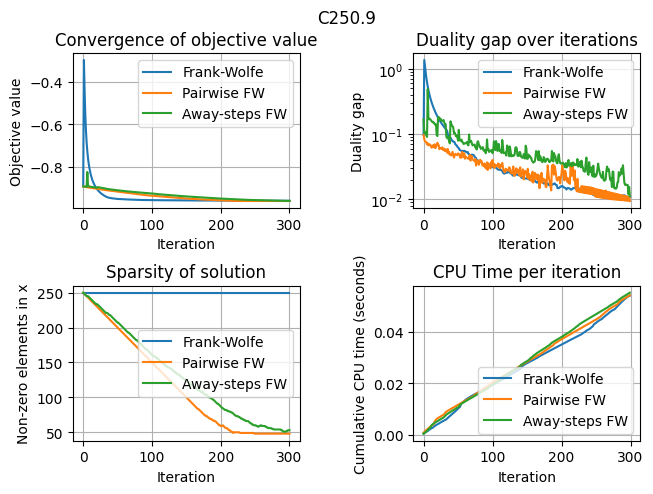

In [21]:
plot_all(history_fw[0], history_pfw[0], history_afw[0], label_suffix = 'C250.9')

### brock200_2 dataset

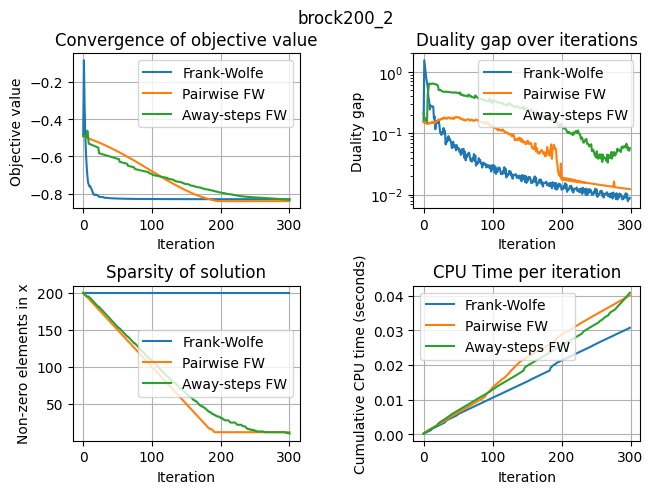

In [22]:
plot_all(history_fw[1], history_pfw[1], history_afw[1], label_suffix = 'brock200_2')

### gen400_p0.9_65 dataset

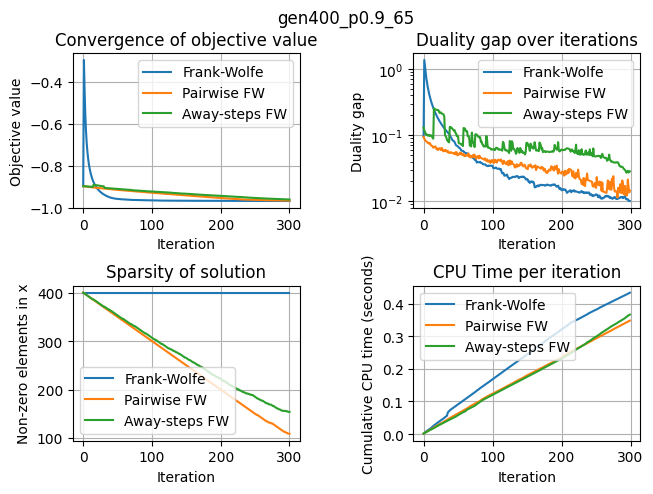

In [23]:
plot_all(history_fw[2], history_pfw[2], history_afw[2], label_suffix = 'gen400_p0.9_65')

### Maximum Clique

In [24]:
def get_max_clique(A, n_graph, traj, threshold=1e-5):
    x_star = [None] * n_graph
    len_x_star = [None] * n_graph

    for i in range(n_graph):
        x_star[i] = sorted(np.where(traj[i][-1] > threshold)[0])

        while True:
            removal_nodes = set()
            for j in range(len(x_star[i])):
                x = x_star[i][j]
                for y in x_star[i][j + 1:]:
                    if A[i][x, y] == 0:
                        removal_nodes.add(x)
                        removal_nodes.add(y)

            if not removal_nodes:
                break

            removal_node = min(removal_nodes, key=lambda node: traj[i][-1][node])

            x_star[i].remove(removal_node)

        len_x_star[i] = len(x_star[i])

    return x_star, len_x_star

max_clique_fw, len_fw = get_max_clique(A, n_graph, traj_fw)
max_clique_pfw, len_pfw = get_max_clique(A, n_graph, traj_pfw)
max_clique_afw, len_afw = get_max_clique(A, n_graph, traj_afw)

In [25]:
df = pd.DataFrame({
    "Filename": filenames,
    "Max Clique FW": len_fw,
    "Max Clique PFW": len_pfw,
    "Max Clique AFW": len_afw
})

print(df)

         Filename  Max Clique FW  Max Clique PFW  Max Clique AFW
0          C250.9             39              39              39
1      brock200_2              8               9               9
2  gen400_p0.9_65             42              36              33


### Summary Analysis

In [26]:
def generate_max_clique(seed, A, n_graph, frank_wolfe_method, lmo, loss, grad, n_iter, tol, params):
    traj = [None] * n_graph

    s = np.random.default_rng(seed)

    for i in range(n_graph):
        x0 = s.random(A[i].shape[0])
        x0 /= x0.sum()

        if params:
            traj[i], _ = frank_wolfe_method(
                f = lambda x: f_objective(x, A[i], loss(x, **params)),
                grad_f = lambda x: grad_f(x, A[i], grad(x, **params)),
                x0 = x0,
                lmo = lmo,
                n_iter = n_iter,
                tol = tol
            )
        else:
            traj[i], _ = frank_wolfe_method(
                f = lambda x: f_objective(x, A[i], loss(x)),
                grad_f = lambda x: grad_f(x, A[i], grad(x)),
                x0 = x0,
                lmo = lmo,
                n_iter = n_iter,
                tol = tol
            )

        x_star = traj[i][-1]

    max_clique, len = get_max_clique(A, n_graph, traj)

    return max_clique, len

In [27]:
def fw_stats(filenames, n_iter_rep, A, n_graph, frank_wolfe_methods, lmo, loss, grad, n_iter, tol, params = None):

    clique_size = [[None for _ in range(n_graph)] for _ in range(n_iter_rep)]
    max_clique_size = [- float('inf')] * n_graph
    max_clique = [None] * n_graph

    n_stats = 7
    n_methods = len(frank_wolfe_methods)
    method_labels = ["FW", "PFW", "AFW"]

    stats = [[None for _ in range((n_stats))] for _ in range(n_graph * n_methods)]
    col_labels = ["Graph", "Method", "Min", "Median", "Max", "Std", "Max-Clique"]

    for k, frank_wolfe_method in enumerate(frank_wolfe_methods):
        for i in range(n_iter_rep):
            clique, clique_size[i] = generate_max_clique(i, A, n_graph, frank_wolfe_method, lmo, loss, grad, n_iter, tol, params)
            for j in range(n_graph):
                if clique_size[i][j] > max_clique_size[j]:
                    max_clique_size[j] = clique_size[i][j]
                    max_clique[j] = clique[j]

        clique_stat = np.array(clique_size)
        val_min = np.min(clique_stat, axis=0)
        val_median = np.median(clique_stat, axis = 0)
        val_max = np.max(clique_stat, axis=0)
        val_std = np.std(clique_stat, axis=0)

        for i in range(n_graph):
            stats[k + i * n_graph][0] = filenames[i]
            stats[k + i * n_graph][1] = method_labels[k]
            stats[k + i * n_graph][2] = val_min[i]
            stats[k + i * n_graph][3] = val_median[i]
            stats[k + i * n_graph][4] = val_max[i]
            stats[k + i * n_graph][5] = val_std[i]
            stats[k + i * n_graph][6] = max_clique[i]

    df = pd.DataFrame(stats, columns = col_labels)

    return df.iloc[:, :n_stats-1]

In [28]:
n_iter_rep = 10
frank_wolfe_methods = [frank_wolfe, pairwise_frank_wolfe, away_steps_frank_wolfe]
n_iter = 1000
tol = 1e-6

In [29]:
df_no_reg = fw_stats(filenames = filenames,
         n_iter_rep = n_iter_rep,
         A = A,
         n_graph = n_graph,
         frank_wolfe_methods = frank_wolfe_methods,
         lmo = lmo,
         loss = loss_no_reg,
         grad = grad_no_reg,
         n_iter = n_iter,
         tol = tol
         )

df_no_reg

,Graph,Method,Min,Median,Max,Std
0,C250.9,FW,33,35.0,36,1.019804
1,C250.9,PFW,36,38.5,40,1.268858
2,C250.9,AFW,37,38.5,40,0.916515
3,brock200_2,FW,7,8.0,8,0.400000
4,brock200_2,PFW,8,9.0,9,0.458258
5,brock200_2,AFW,8,8.5,9,0.500000
6,gen400_p0.9_65,FW,38,40.0,42,1.374773
7,gen400_p0.9_65,PFW,33,39.5,43,2.947881
8,gen400_p0.9_65,AFW,32,37.0,44,4.124318


In [30]:
df_reg_B = fw_stats(filenames = filenames,
         n_iter_rep = n_iter_rep,
         A = A,
         n_graph = n_graph,
         frank_wolfe_methods = frank_wolfe_methods,
         lmo = lmo,
         loss = loss_reg_B,
         grad = grad_reg_B,
         n_iter = n_iter,
         tol = tol
         )

df_reg_B

,Graph,Method,Min,Median,Max,Std
0,C250.9,FW,37,39.0,42,1.624808
1,C250.9,PFW,38,39.0,41,0.943398
2,C250.9,AFW,35,40.0,42,1.857418
3,brock200_2,FW,8,8.5,10,0.663325
4,brock200_2,PFW,8,9.0,10,0.640312
5,brock200_2,AFW,7,8.0,10,0.800000
6,gen400_p0.9_65,FW,40,44.5,47,2.193171
7,gen400_p0.9_65,PFW,32,36.0,43,3.072458
8,gen400_p0.9_65,AFW,34,37.0,45,3.200000


In [31]:
df_reg_1 = fw_stats(filenames = filenames,
         n_iter_rep = n_iter_rep,
         A = A,
         n_graph = n_graph,
         frank_wolfe_methods = frank_wolfe_methods,
         lmo = lmo,
         loss = loss_reg_1,
         grad = grad_reg_1,
         n_iter = n_iter,
         tol = tol,
         params = {"epsilon": 1e-9, "p": 3, "alpha": 0.25}
         )

df_reg_1

,Graph,Method,Min,Median,Max,Std
0,C250.9,FW,36,38.0,42,1.676305
1,C250.9,PFW,36,39.5,42,2.193171
2,C250.9,AFW,38,39.5,42,1.100000
3,brock200_2,FW,8,9.0,9,0.458258
4,brock200_2,PFW,8,9.0,9,0.458258
5,brock200_2,AFW,7,9.0,10,0.800000
6,gen400_p0.9_65,FW,40,43.5,48,2.247221
7,gen400_p0.9_65,PFW,32,36.0,40,2.410394
8,gen400_p0.9_65,AFW,32,36.5,54,6.587868


In [32]:
df_reg_2 = fw_stats(filenames = filenames,
         n_iter_rep = n_iter_rep,
         A = A,
         n_graph = n_graph,
         frank_wolfe_methods = frank_wolfe_methods,
         lmo = lmo,
         loss = loss_reg_2,
         grad = grad_reg_2,
         n_iter = n_iter,
         tol = tol,
         params = {"beta": 5, "alpha": 0.05}
         )

df_reg_2

,Graph,Method,Min,Median,Max,Std
0,C250.9,FW,37,38.5,42,1.673320
1,C250.9,PFW,39,40.0,43,1.280625
2,C250.9,AFW,36,40.0,41,1.417745
3,brock200_2,FW,8,8.5,10,0.663325
4,brock200_2,PFW,8,9.0,10,0.774597
5,brock200_2,AFW,8,9.0,10,0.700000
6,gen400_p0.9_65,FW,41,45.5,48,1.868154
7,gen400_p0.9_65,PFW,32,36.5,42,3.400000
8,gen400_p0.9_65,AFW,33,36.0,51,6.410148
